In [8]:
import pandas as pd

df = pd.read_csv('/train.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [9]:
df.shape

(9800, 18)

In [10]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [11]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [14]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [15]:
df.nunique()


,0
Row ID,9800
Order ID,4922
Order Date,1230
Ship Date,1326
Ship Mode,4
Customer ID,793
Customer Name,793
Segment,3
Country,1
City,529


In [16]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [17]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

In [18]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [19]:
df[['Order Date', 'Ship Date']].isnull().sum()


,0
Order Date,5841
Ship Date,5985


In [20]:
df[['Order Date', 'Ship Date']].head(10)

,Order Date,Ship Date
0,2017-08-11,2017-11-11
1,2017-08-11,2017-11-11
2,2017-12-06,NaT
3,2016-11-10,NaT
4,2016-11-10,NaT
5,2015-09-06,NaT
6,2015-09-06,NaT
7,2015-09-06,NaT
8,2015-09-06,NaT
9,2015-09-06,NaT


In [21]:
original_df = pd.read_csv('/train.csv')

original_df[['Order Date', 'Ship Date']].head(20)

,Order Date,Ship Date
0,08/11/2017,11/11/2017
1,08/11/2017,11/11/2017
2,12/06/2017,16/06/2017
3,11/10/2016,18/10/2016
4,11/10/2016,18/10/2016
5,09/06/2015,14/06/2015
6,09/06/2015,14/06/2015
7,09/06/2015,14/06/2015
8,09/06/2015,14/06/2015
9,09/06/2015,14/06/2015


In [22]:
df = original_df.copy()

df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d/%m/%Y',
    errors='coerce'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='%d/%m/%Y',
    errors='coerce'
)

df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [23]:
df[['Order Date', 'Ship Date']].isnull().sum()

,0
Order Date,0
Ship Date,0


In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [26]:
df[df['Postal Code'].isnull()][['City', 'State', 'Postal Code']]

,City,State,Postal Code
2234,Burlington,Vermont,NaN
5274,Burlington,Vermont,NaN
8798,Burlington,Vermont,NaN
9146,Burlington,Vermont,NaN
9147,Burlington,Vermont,NaN
9148,Burlington,Vermont,NaN
9386,Burlington,Vermont,NaN
9387,Burlington,Vermont,NaN
9388,Burlington,Vermont,NaN
9389,Burlington,Vermont,NaN


In [27]:
df[df['Postal Code'].isnull()][['City', 'State']]

,City,State
2234,Burlington,Vermont
5274,Burlington,Vermont
8798,Burlington,Vermont
9146,Burlington,Vermont
9147,Burlington,Vermont
9148,Burlington,Vermont
9386,Burlington,Vermont
9387,Burlington,Vermont
9388,Burlington,Vermont
9389,Burlington,Vermont


In [28]:
df['Postal Code'] = df.groupby('State')['Postal Code'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0)
)

In [29]:
df['Postal Code'].isnull().sum()

np.int64(0)

In [31]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales']

In [32]:
df['Sales'].describe()

,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


In [33]:
df.select_dtypes(include='object').isnull().sum()

,0
Order ID,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0
State,0
Region,0
Product ID,0


In [34]:
df.select_dtypes(include='object').nunique()

,0
Order ID,4922
Ship Mode,4
Customer ID,793
Customer Name,793
Segment,3
Country,1
City,529
State,49
Region,4
Product ID,1861


In [35]:
df['Category'].value_counts()

,count
Category,
Office Supplies,5909
Furniture,2078
Technology,1813


In [36]:
df['Ship Mode'].value_counts()

,count
Ship Mode,
Standard Class,5859
Second Class,1902
First Class,1501
Same Day,538


In [37]:
df['Segment'].value_counts()

,count
Segment,
Consumer,5101
Corporate,2953
Home Office,1746


In [38]:
df['Region'].value_counts()

,count
Region,
West,3140
East,2785
Central,2277
South,1598


In [39]:
df['State'].value_counts()

,count
State,
California,1946
New York,1097
Texas,973
Pennsylvania,582
Washington,504
Illinois,483
Ohio,454
Florida,373
Michigan,253


In [40]:
df['Product Name'].duplicated().sum()

np.int64(7951)

In [41]:
df.shape

(9800, 18)

In [42]:
df.to_csv('/cleaned_superstore.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [43]:
from google.colab import files

files.download('/cleaned_superstore.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/cleaned_superstore.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [45]:
print("Sales Descriptive Statistics")
print("----------------------------")

print("Mean Sales:", df['Sales'].mean())
print("Median Sales:", df['Sales'].median())
print("Minimum Sales:", df['Sales'].min())
print("Maximum Sales:", df['Sales'].max())

Sales Descriptive Statistics
----------------------------
Mean Sales: 230.7690594591837
Median Sales: 54.489999999999995
Minimum Sales: 0.444
Maximum Sales: 22638.48


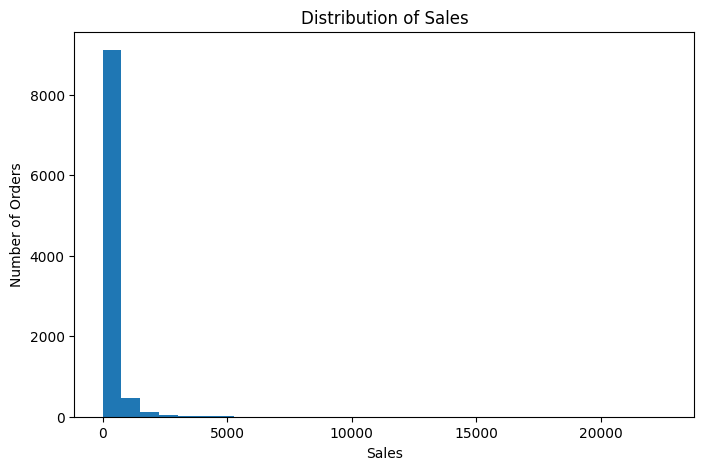

In [46]:
plt.figure(figsize=(8,5))

plt.hist(df['Sales'], bins=30)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Number of Orders')

plt.show()

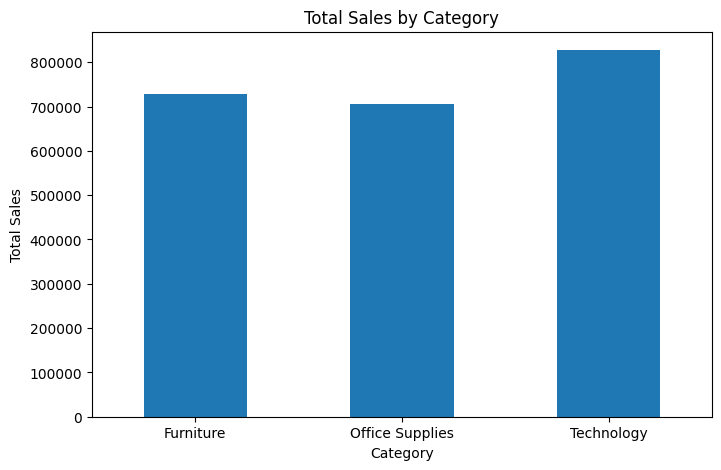

In [47]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)
plt.show()

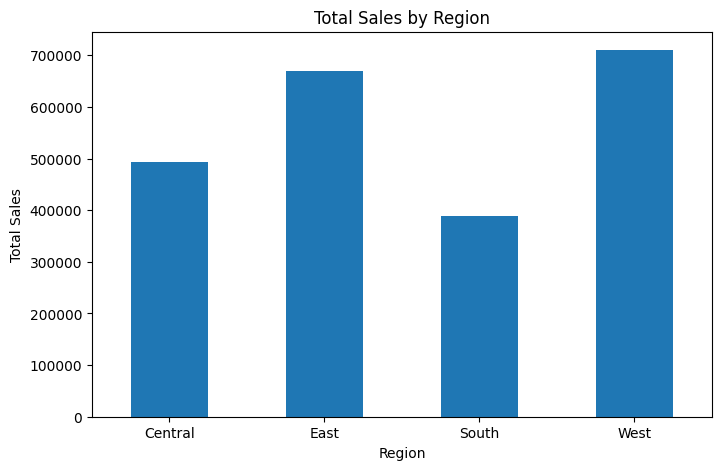

In [48]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)
plt.show()

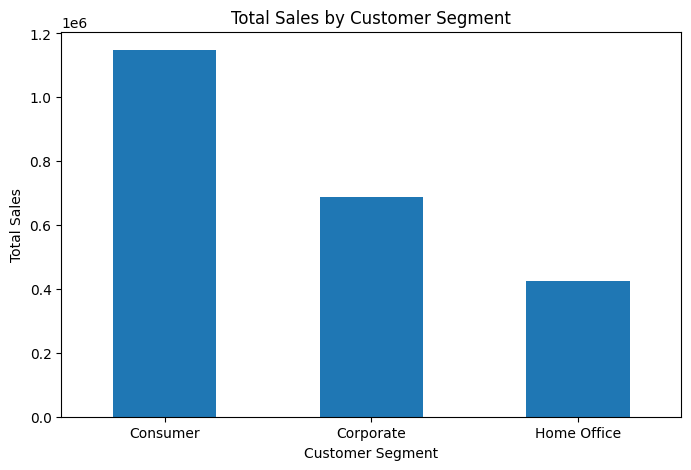

In [49]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(8,5))

segment_sales.plot(kind='bar')

plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)
plt.show()

<Figure size 1000x600 with 0 Axes>

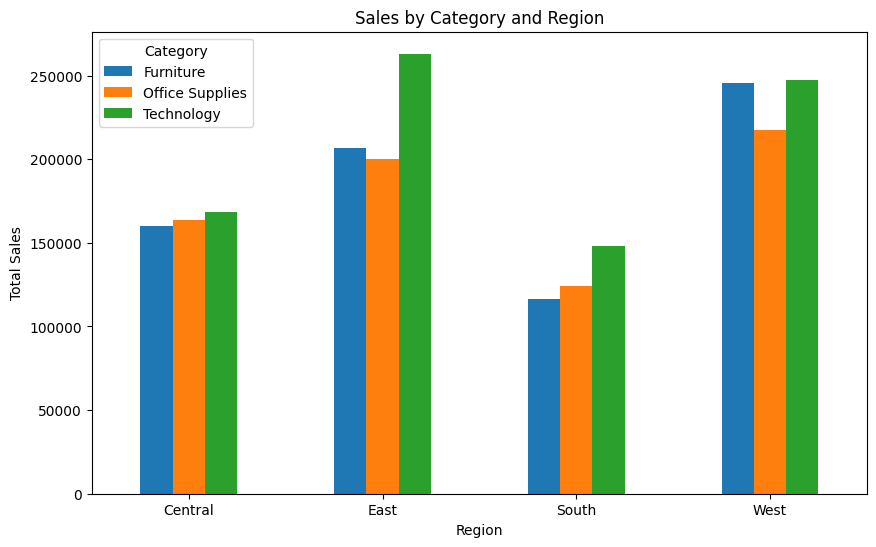

In [50]:
category_region_sales = df.pivot_table(
    values='Sales',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))

category_region_sales.plot(kind='bar', figsize=(10,6))

plt.title('Sales by Category and Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)
plt.legend(title='Category')
plt.show()

## EDA Conclusion

The exploratory data analysis helped identify important patterns in the Superstore dataset. Descriptive statistics were used to understand the distribution of sales. The visualizations compared sales across product categories, regions, and customer segments.

The analysis shows that sales are unevenly distributed, with some orders contributing much higher sales than others. Comparing categories, regions, and customer segments helps identify areas that contribute more to overall sales.

These findings provide a useful foundation for further analysis and business decision-making.
